In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

np.random.seed(42)
tf.random.set_seed(42)

os.makedirs('models', exist_ok=True)
os.makedirs('images', exist_ok=True)

EDGE_TYPES = {
    0: 'Horizontal',  1: 'Vertical',
    2: 'Diag BL-TR',  3: 'Diag TL-BR',
    4: 'Corner TL',   5: 'Corner TR',
    6: 'Corner BL',   7: 'Corner BR',
    8: 'T-Top',       9: 'T-Bottom',
    10: 'Cross',      11: 'No Edge'
}
NUM_CLASSES = 12
PATCH_SIZE  = 5
PAD         = PATCH_SIZE // 2

print('TF version:', tf.__version__)

TF version: 2.20.0


In [6]:
import sys
!{sys.executable} -m pip install opencv-python

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)


In [7]:
import cv2
print(cv2.__version__)

4.13.0


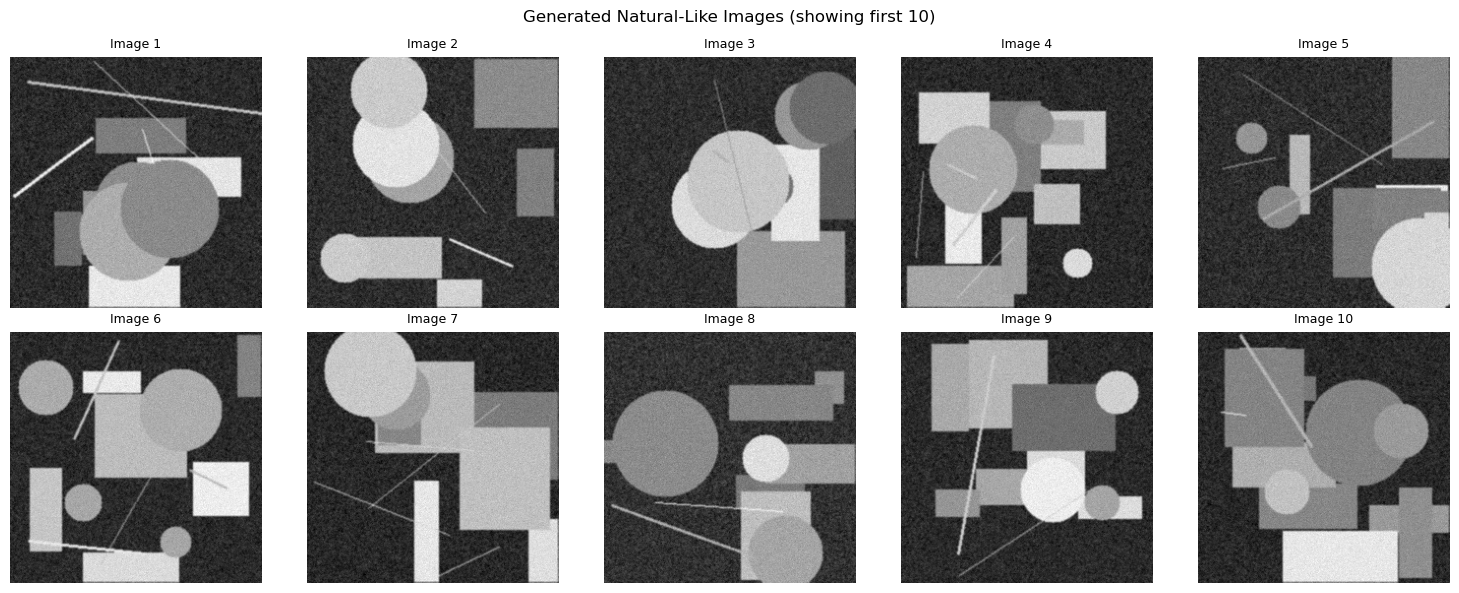

Generated 30 images.


In [ ]:
def make_natural_image(size=256, seed=None):
    if seed is not None:
        np.random.seed(seed)

    # Random noisy background
    img = np.random.randint(20, 80, (size, size), dtype=np.uint8)

    # Random rectangles
    for _ in range(np.random.randint(4, 9)):
        x1 = np.random.randint(0, size - 20)
        y1 = np.random.randint(0, size - 20)
        x2 = min(x1 + np.random.randint(20, 120), size - 1)
        y2 = min(y1 + np.random.randint(20, 120), size - 1)
        img[y1:y2, x1:x2] = np.random.randint(90, 240)

    # Random circles
    for _ in range(np.random.randint(2, 6)):
        cx = int(np.random.randint(30, size - 30))
        cy = int(np.random.randint(30, size - 30))
        r  = int(np.random.randint(15, 55))
        cv2.circle(img, (cx, cy), r, int(np.random.randint(100, 240)), -1)

    # Random lines
    for _ in range(np.random.randint(2, 5)):
        pt1 = (int(np.random.randint(0, size)), int(np.random.randint(0, size)))
        pt2 = (int(np.random.randint(0, size)), int(np.random.randint(0, size)))
        cv2.line(img, pt1, pt2, int(np.random.randint(150, 255)), int(np.random.randint(1, 3)))

    # Blur + mild noise to mimic real image stats
    img = cv2.GaussianBlur(img, (3, 3), 0.8)
    noise = np.random.normal(0, 7, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img


natural_images = [make_natural_image(256, seed=i) for i in range(30)]

# Preview
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(natural_images[i], cmap='gray')
    ax.set_title(f'Image {i+1}', fontsize=9)
    ax.axis('off')
plt.suptitle('Generated Natural-Like Images (showing first 10)', fontsize=12)
plt.tight_layout()
plt.savefig('images/natural_images_preview.png', dpi=100)
plt.show()
print(f'Generated {len(natural_images)} images.')

In [10]:
def get_pseudo_label(patch):
    """Assign an edge type label to a 5x5 patch based on Sobel gradient orientation."""
    pf = patch.astype(np.float32)
    gx = cv2.Sobel(pf, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(pf, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(gx**2 + gy**2)

    if mag.max() < 8:
        return 11  # No Edge

    # Strong gradients in both directions → junction or corner
    h_strength = float(np.abs(gx[:, 2]).mean())
    v_strength = float(np.abs(gy[2, :]).mean())

    if h_strength > 10 and v_strength > 10:
        top    = float(mag[:2, :].mean())
        bottom = float(mag[3:, :].mean())
        left   = float(mag[:, :2].mean())
        right  = float(mag[:, 3:].mean())
        mx = max(top, bottom, left, right)

        if mx < 5:          return 10  # Cross
        elif top == mx:     return 8   # T-Top
        elif bottom == mx:  return 9   # T-Bottom
        elif left > right:  return 4 if top > bottom else 6   # Corner TL or BL
        else:               return 5 if top > bottom else 7   # Corner TR or BR

    # Single dominant direction
    w = mag / (mag.sum() + 1e-8)
    angle = float(np.sum(np.arctan2(np.abs(gy), np.abs(gx)) * w)) * (180 / np.pi)

    if angle < 22.5:    return 0   # Horizontal
    elif angle < 67.5:  return 3   # Diagonal TL-BR
    elif angle < 112.5: return 1   # Vertical
    else:               return 2   # Diagonal BL-TR


def extract_patches(gray_img, max_edge=400, max_noedge=200):
    """Extract labeled 5x5 patches from a grayscale image."""
    padded = cv2.copyMakeBorder(gray_img, PAD, PAD, PAD, PAD, cv2.BORDER_REFLECT)
    edges  = cv2.Canny(gray_img, 40, 120)

    edge_pixels   = list(zip(*np.where(edges > 0)))
    noedge_pixels = list(zip(*np.where(edges == 0)))
    np.random.shuffle(edge_pixels)
    np.random.shuffle(noedge_pixels)

    patches, labels = [], []

    for (r, c) in edge_pixels[:max_edge]:
        raw = padded[r:r+PATCH_SIZE, c:c+PATCH_SIZE]
        patches.append(raw.astype(np.float32) / 255.0)
        labels.append(get_pseudo_label(raw))

    for (r, c) in noedge_pixels[:max_noedge]:
        raw = padded[r:r+PATCH_SIZE, c:c+PATCH_SIZE]
        patches.append(raw.astype(np.float32) / 255.0)
        labels.append(11)

    return patches, labels


print('Functions ready. Extracting patches...')

Functions ready. Extracting patches...


In [11]:
all_patches, all_labels = [], []

for i, img in enumerate(natural_images):
    p, l = extract_patches(img)
    all_patches.extend(p)
    all_labels.extend(l)

X_nat = np.array(all_patches).reshape(-1, PATCH_SIZE, PATCH_SIZE, 1).astype(np.float32)
y_nat = np.array(all_labels)

print(f'Total natural patches: {X_nat.shape[0]}')
print('Class distribution:')
for cls_id, count in zip(*np.unique(y_nat, return_counts=True)):
    print(f'  [{cls_id:2d}] {EDGE_TYPES[cls_id]:<15}: {count}')

Total natural patches: 18000
Class distribution:
  [ 0] Horizontal     : 80
  [ 1] Vertical       : 79
  [ 3] Diag TL-BR     : 532
  [ 4] Corner TL      : 1409
  [ 5] Corner TR      : 1398
  [ 6] Corner BL      : 1457
  [ 7] Corner BR      : 1435
  [ 8] T-Top          : 2764
  [ 9] T-Bottom       : 2846
  [11] No Edge        : 6000


In [12]:
X_syn = np.load('X_synthetic.npy')
y_syn = np.load('y_synthetic.npy')

n_syn = int(0.20 * len(X_syn))
idx   = np.random.choice(len(X_syn), size=n_syn, replace=False)

X_combined = np.concatenate([X_nat, X_syn[idx]], axis=0)
y_combined = np.concatenate([y_nat, y_syn[idx]], axis=0)

# Shuffle combined set
shuf = np.random.permutation(len(X_combined))
X_combined = X_combined[shuf]
y_combined = y_combined[shuf]

print(f'Combined: {len(X_combined)} patches  (natural={len(X_nat)}, synthetic={n_syn})')

X_train, X_val, y_train, y_val = train_test_split(
    X_combined, y_combined, test_size=0.15, stratify=y_combined, random_state=42
)
print(f'Train: {len(X_train)}  |  Val: {len(X_val)}')

Combined: 20400 patches  (natural=18000, synthetic=2400)
Train: 17340  |  Val: 3060


In [13]:
model = tf.keras.models.load_model('models/edge_cnn_v1_final.keras')

# Freeze only the first layer
model.layers[0].trainable = False

print('Layer trainability:')
for i, layer in enumerate(model.layers):
    print(f'  [{i}] {layer.name:<25} trainable={layer.trainable}')

Layer trainability:
  [0] conv2d                    trainable=False
  [1] batch_normalization       trainable=True
  [2] conv2d_1                  trainable=True
  [3] batch_normalization_1     trainable=True
  [4] flatten                   trainable=True
  [5] dense                     trainable=True
  [6] dropout                   trainable=True
  [7] dense_1                   trainable=True


In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cbs = [
    callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('models/edge_cnn_v2_best.keras',
                              monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=cbs,
    verbose=1
)

Epoch 1/40
263/271 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3364 - loss: 4.7215
Epoch 1: val_accuracy improved from None to 0.41111, saving model to models/edge_cnn_v2_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.3660 - loss: 2.6942 - val_accuracy: 0.4111 - val_loss: 1.6316 - learning_rate: 1.0000e-04
Epoch 2/40
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4026 - loss: 1.7092
Epoch 2: val_accuracy improved from 0.41111 to 0.42353, saving model to models/edge_cnn_v2_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4070 - loss: 1.6760 - val_accuracy: 0.4235 - val_loss: 1.5658 - learning_rate: 1.0000e-04
Epoch 3/40
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4228 - loss: 1.6257
Epoch 3: val_accuracy improved from 0.42353 to 0.44967, saving model to models/edge_cnn_v2_best.keras
271/271 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4249 - loss: 1.6174 - val_accuracy: 0.4497 - val_loss: 1.5298 - learning_rate: 1.0000e-04
Epoc

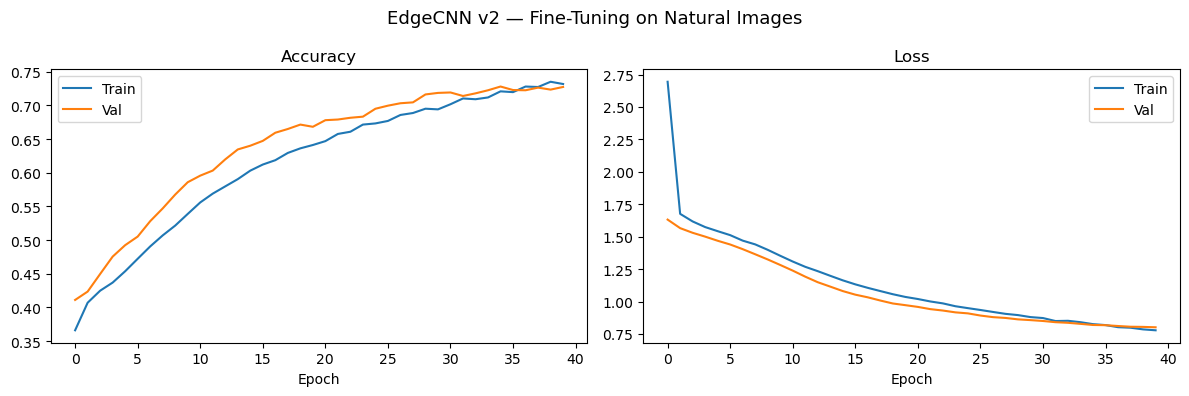

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.suptitle('EdgeCNN v2 — Fine-Tuning on Natural Images', fontsize=13)
plt.tight_layout()
plt.savefig('images/training_curves_v2.png', dpi=120)
plt.show()

In [16]:
loss, acc = model.evaluate(X_val, y_val, verbose=0)
print(f'Val Accuracy : {acc*100:.2f}%')
print(f'Val Loss     : {loss:.4f}\n')

y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
print(classification_report(y_val, y_pred,
      target_names=list(EDGE_TYPES.values()), zero_division=0))

Val Accuracy : 72.75%
Val Loss     : 0.8015

              precision    recall  f1-score   support

  Horizontal       0.92      0.79      0.85        42
    Vertical       1.00      0.76      0.86        42
  Diag BL-TR       1.00      1.00      1.00        32
  Diag TL-BR       0.90      0.24      0.38       108
   Corner TL       0.71      0.56      0.63       246
   Corner TR       0.66      0.56      0.61       237
   Corner BL       0.72      0.66      0.69       252
   Corner BR       0.72      0.59      0.65       246
       T-Top       0.69      0.79      0.74       446
    T-Bottom       0.68      0.77      0.72       455
       Cross       1.00      1.00      1.00        26
     No Edge       0.75      0.85      0.80       928

    accuracy                           0.73      3060
   macro avg       0.81      0.71      0.74      3060
weighted avg       0.73      0.73      0.72      3060



In [18]:
model.save('models/edge_cnn_v2_final.keras')
print('Saved: models/edge_cnn_v2_final.keras')

Saved: models/edge_cnn_v2_final.keras
